In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("../data/instagram_users.csv")
df.head()

,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
0,0.001,0.257,13,1,1,13,0,0,0,0,0,0,1
1,0.000,0.958,9,1,0,0,0,1,0,0,0,0,1
2,0.000,0.253,12,0,0,0,0,0,0,0,0,0,1
3,0.000,0.977,10,1,0,0,0,0,0,0,0,0,1
4,0.000,0.321,11,0,0,11,1,0,0,0,0,0,1


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB


edge_followed_by        0
edge_follow             0
username_length         0
username_has_number     0
full_name_has_number    0
full_name_length        0
is_private              0
is_joined_recently      0
has_channel             0
is_business_account     0
has_guides              0
has_external_url        0
is_fake                 0
dtype: int64

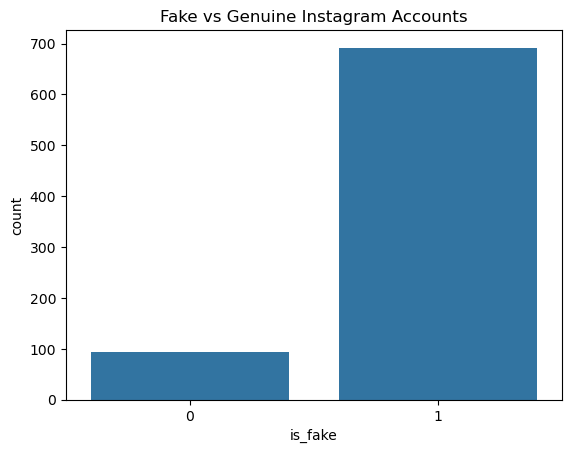

In [6]:
# Target distribution
sns.countplot(x="is_fake", data=df)
plt.title("Fake vs Genuine Instagram Accounts")
plt.show()

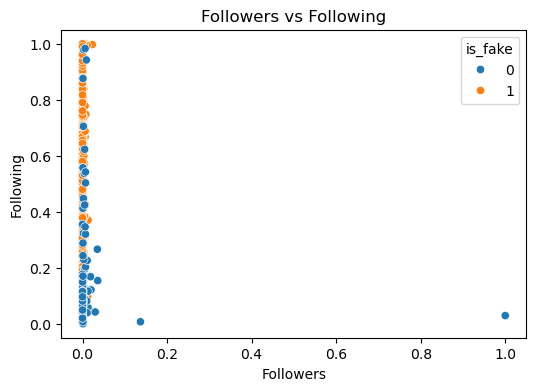

In [7]:
# Followers vs Following
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="edge_followed_by",
    y="edge_follow",
    hue="is_fake",
    data=df
)
plt.xlabel("Followers")
plt.ylabel("Following")
plt.title("Followers vs Following")
plt.show()

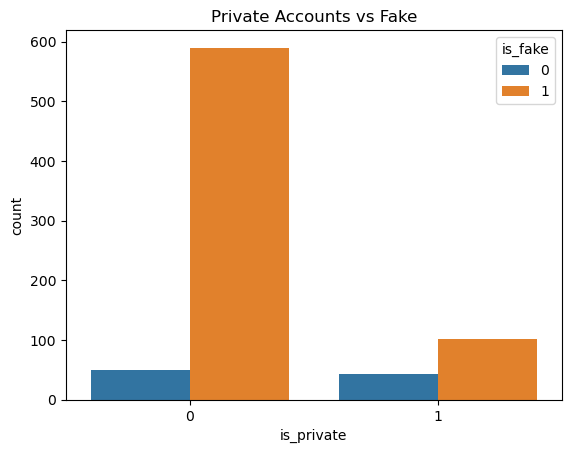

In [8]:
#Private Account Analysis
sns.countplot(x="is_private", hue="is_fake", data=df)
plt.title("Private Accounts vs Fake")
plt.show()

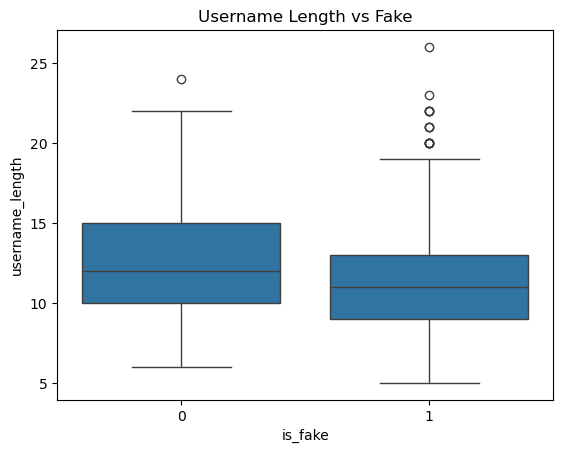

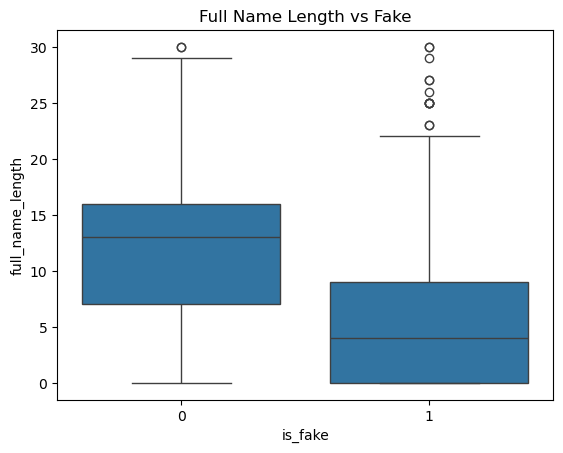

In [9]:
#Username & Full Name Patterns
sns.boxplot(x="is_fake", y="username_length", data=df)
plt.title("Username Length vs Fake")
plt.show()

sns.boxplot(x="is_fake", y="full_name_length", data=df)
plt.title("Full Name Length vs Fake")
plt.show()

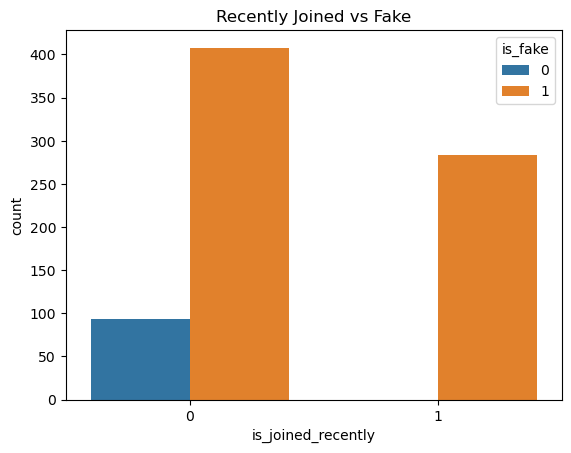

In [10]:
#Recently Joined Accounts
sns.countplot(x="is_joined_recently", hue="is_fake", data=df)
plt.title("Recently Joined vs Fake")
plt.show()

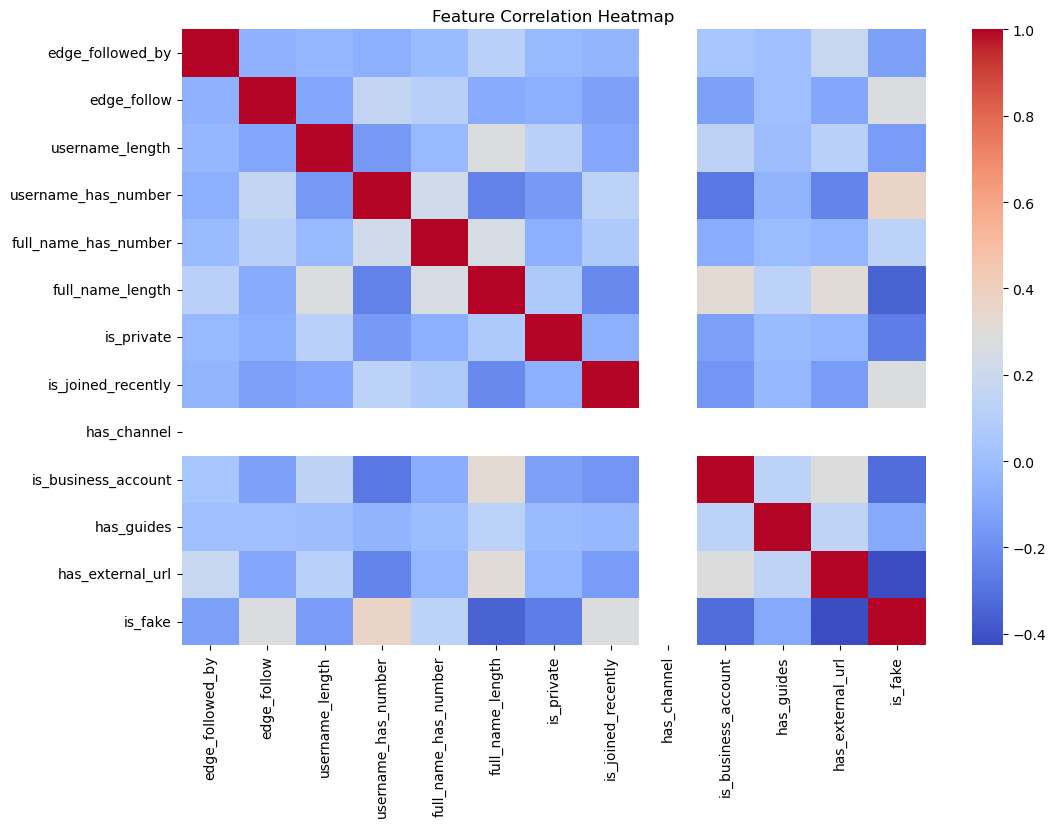

In [11]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

## data preprocessing

In [12]:
X = df.drop("is_fake", axis=1)
y = df["is_fake"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## model training

In [15]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred_lr = lr.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9235668789808917

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.63      0.67        19
           1       0.95      0.96      0.96       138

    accuracy                           0.92       157
   macro avg       0.83      0.80      0.81       157
weighted avg       0.92      0.92      0.92       157



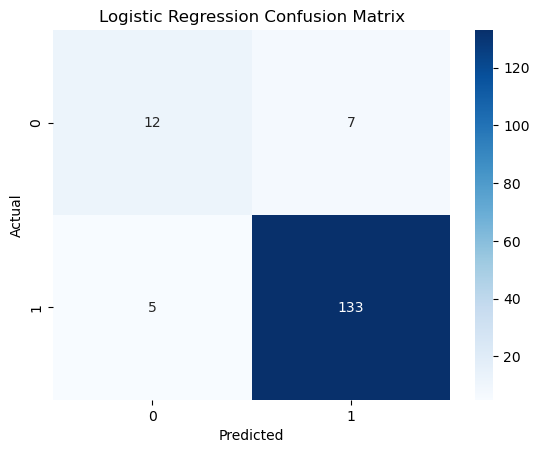

In [18]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [20]:
y_pred_rf = rf.predict(X_test)

In [21]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9426751592356688

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.63      0.73        19
           1       0.95      0.99      0.97       138

    accuracy                           0.94       157
   macro avg       0.90      0.81      0.85       157
weighted avg       0.94      0.94      0.94       157



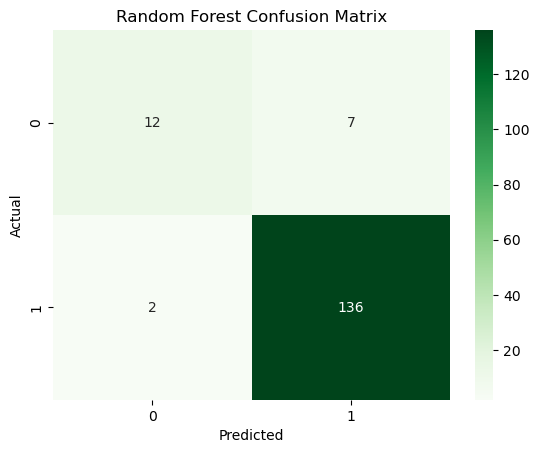

In [22]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

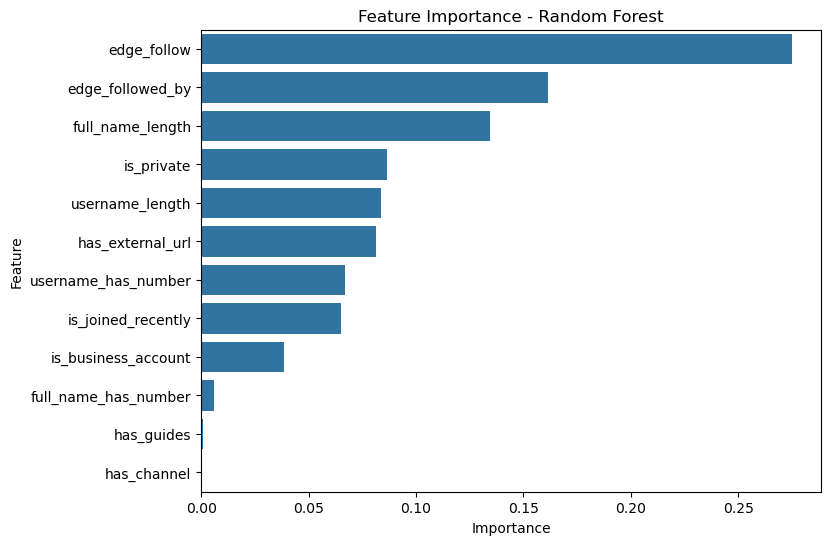

In [23]:
# feature importance
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)
plt.title("Feature Importance - Random Forest")
plt.show()